In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# SET-UP GENERAL 

In [2]:
# ============================================================
# JAGUAR Re-Identification Challenge
# MODELING PIPELINE - BASELINE SERIO DE REID
# ============================================================

import os
import gc
import math
import random
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
from timm.utils import ModelEmaV2
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision.transforms as T

import timm

warnings.filterwarnings("ignore")

# Reproducibilidad
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Para reproducibilidad; si quieres máxima velocidad, puedes relajar esto luego
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

print("Setup listo.")
print("Torch version:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Setup listo.
Torch version: 2.9.0+cu126
CUDA disponible: True
GPU: Tesla P100-PCIE-16GB


# CONFIGURACION CENTRAL

In [3]:
# ============================================================
# CONFIG CENTRAL
# ============================================================

@dataclass
class CFG:
    # -------------------------
    # Paths
    # -------------------------
    train_csv_dir: str = "/kaggle/input/datasets/damontoyat/train-csv-jaguars"
    train_img_dir: str = "/kaggle/input/datasets/damontoyat/train-jaguars"

    # -------------------------
    # Test paths
    # -------------------------
    test_csv_path: str = "/kaggle/input/datasets/damontoyat/test-csv-jaguars"
    sample_submission_path: str = "/kaggle/input/datasets/damontoyat/sample-submission-jaguars"
    test_img_dir: str = "/kaggle/input/datasets/damontoyat/test-jaguars"
    
    # -------------------------
    # Offline preprocessing test
    # -------------------------
    offline_test_dir: str = "/kaggle/working/preprocessed_test_320"

    # -------------------------
    # General
    # -------------------------
    seed: int = 42
    n_splits: int = 5
    fold: int = 0                # fold activo para experimentos rápidos
    run_all_folds: bool = True  # True si luego quieres CV completa

    # -------------------------
    # Image / preprocessing
    # -------------------------
    image_size: int = 384
    use_alpha_crop: bool = True
    alpha_background: str = "black"   # "black" o "white"
    keep_aspect_ratio: bool = True

    # -------------------------
    # Offline preprocessing
    # -------------------------
    use_offline_preprocessed: bool = True
    offline_train_dir: str = "/kaggle/working/preprocessed_train_384"
    offline_test_dir: str = "/kaggle/working/preprocessed_test_384"
    offline_image_format: str = "jpg"
    offline_jpg_quality: int = 95
    # -------------------------
    # Augmentations
    # -------------------------
    use_train_aug: bool = True
    hflip_prob: float = 0.5
    color_jitter_prob: float = 0.5
    rotation_degrees: float = 8.0
    translate: float = 0.05
    scale_min: float = 0.95
    scale_max: float = 1.05

    # -------------------------
    # Model
    # -------------------------
    model_name: str = "hf-hub:BVRA/MegaDescriptor-L-384"
    embedding_dim: int = 1024
    dropout: float = 0.1

    # head_type:
    # - "arcface" = más alineado con ReID
    # - "linear"  = baseline más simple
    head_type: str = "arcface"

    # ArcFace
    arcface_s: float = 30.0
    arcface_m: float = 0.35

    # -------------------------
    # Training
    # -------------------------
    epochs: int = 15
    warmup_epochs: int = 1
    batch_size: int = 8
    backbone_lr: float = 5e-5
    head_lr: float = 1e-4
    num_workers: int = 4

    # -------------------------
    # EMA
    # -------------------------
    use_ema: bool = True
    ema_decay: float = 0.995

    # learning rates separados
    backbone_lr: float = 1e-4
    head_lr: float = 5e-4
    weight_decay: float = 1e-4

    # scheduler
    min_lr: float = 1e-6

    # class imbalance
    use_weighted_sampler: bool = True

    # mixed precision
    use_amp: bool = True

    # logging / save
    output_dir: str = "/kaggle/working/jaguar_reid_outputs_mega384"

cfg = CFG()

os.makedirs(cfg.output_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(cfg)
print("Device:", device)

CFG(train_csv_dir='/kaggle/input/datasets/damontoyat/train-csv-jaguars', train_img_dir='/kaggle/input/datasets/damontoyat/train-jaguars', test_csv_path='/kaggle/input/datasets/damontoyat/test-csv-jaguars', sample_submission_path='/kaggle/input/datasets/damontoyat/sample-submission-jaguars', test_img_dir='/kaggle/input/datasets/damontoyat/test-jaguars', offline_test_dir='/kaggle/working/preprocessed_test_384', seed=42, n_splits=5, fold=0, run_all_folds=True, image_size=384, use_alpha_crop=True, alpha_background='black', keep_aspect_ratio=True, use_offline_preprocessed=True, offline_train_dir='/kaggle/working/preprocessed_train_384', offline_image_format='jpg', offline_jpg_quality=95, use_train_aug=True, hflip_prob=0.5, color_jitter_prob=0.5, rotation_degrees=8.0, translate=0.05, scale_min=0.95, scale_max=1.05, model_name='hf-hub:BVRA/MegaDescriptor-L-384', embedding_dim=1024, dropout=0.1, head_type='arcface', arcface_s=30.0, arcface_m=0.35, epochs=15, warmup_epochs=1, batch_size=8, back

# FASE 3- FEATURE ENGINEERING

1. cargar metadata

2. label encoding

3. crear folds

4. preprocessing con alpha

5. augmentations

6. sampler balanceado

### CARGAR METADATA Y LABEL ENCODING

In [4]:
# ============================================================
# CARGA DE METADATA
# ============================================================

CSV_DIR = Path(cfg.train_csv_dir)
IMG_DIR = Path(cfg.train_img_dir)

csv_files = list(CSV_DIR.rglob("*.csv"))
assert len(csv_files) > 0, "No se encontró CSV de train."

train_csv_path = csv_files[0]
train_df = pd.read_csv(train_csv_path)

# Mapear full_path
image_files = list(IMG_DIR.rglob("*.png"))
name_to_path = {p.name: str(p) for p in image_files}

train_df["full_path"] = train_df["filename"].map(name_to_path)

assert train_df["full_path"].isnull().sum() == 0, "Hay imágenes sin path."

# Label encoding
le = LabelEncoder()
train_df["label"] = le.fit_transform(train_df["ground_truth"])
num_classes = train_df["label"].nunique()

print("Shape train_df:", train_df.shape)
print("Número de clases:", num_classes)
display(train_df.head())

Shape train_df: (1895, 4)
Número de clases: 31


,filename,ground_truth,full_path,label
0,train_0001.png,Abril,/kaggle/input/datasets/damontoyat/train-jaguar...,0
1,train_0002.png,Abril,/kaggle/input/datasets/damontoyat/train-jaguar...,0
2,train_0003.png,Abril,/kaggle/input/datasets/damontoyat/train-jaguar...,0
3,train_0004.png,Akaloi,/kaggle/input/datasets/damontoyat/train-jaguar...,1
4,train_0005.png,Akaloi,/kaggle/input/datasets/damontoyat/train-jaguar...,1


### CREAR FOLDS

Por qué StratifiedKFold

Queremos que cada fold tenga representación de todas las identidades.

Nota importante

Idealmente usaríamos una agrupación por near-duplicates, pero como no tenemos ids de sesión/fotógrafo, arrancamos con:

StratifiedKFold por label

In [5]:
# ============================================================
# FOLDS DE VALIDACION
# ============================================================

train_df["fold"] = -1

skf = StratifiedKFold(
    n_splits=cfg.n_splits,
    shuffle=True,
    random_state=cfg.seed
)

for fold, (_, valid_idx) in enumerate(skf.split(train_df, train_df["label"])):
    train_df.loc[valid_idx, "fold"] = fold

print(train_df["fold"].value_counts().sort_index())
display(train_df.groupby(["fold", "ground_truth"]).size().head(20))

fold
0    379
1    379
2    379
3    379
4    379
Name: count, dtype: int64


fold  ground_truth
0     Abril            5
      Akaloi           3
      Alira            4
      Apeiara          4
      Ariely           7
      Bagua           12
      Benita          17
      Bernard          3
      Bororo           4
      Estella          4
      Guaraci          6
      Ipepo            2
      Jaju            21
      Kamaikua        21
      Katniss         13
      Kwang           22
      Lua             24
      Madalena         6
      Marcela         36
      Medrosa         34
dtype: int64

### Procesamiento con Alpha

Qué hace

1.abre la imagen RGBA

2.usa alpha para ubicar el jaguar

3.recorta al bounding box visible

4.compone la imagen sobre fondo negro o blanco

5.redimensiona preservando proporción

6.hace padding a cuadrado

Por qué se hace

Porque el test oculto trae background en RGB y alpha mask.
Si usamos alpha desde el inicio, reducimos el riesgo de que el modelo aprenda fondo.

In [6]:
# ============================================================
# PREPROCESSING VISUAL CON ALPHA
# ============================================================

def alpha_crop_rgba(img: Image.Image) -> Image.Image:
    """
    Recorta una imagen RGBA al bounding box definido por alpha > 0.
    Si no encuentra pixeles visibles, devuelve la imagen original.
    """
    arr = np.array(img)
    alpha = arr[:, :, 3]
    mask = alpha > 0

    if not mask.any():
        return img

    ys, xs = np.where(mask)
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()

    cropped = arr[y_min:y_max+1, x_min:x_max+1, :]
    return Image.fromarray(cropped, mode="RGBA")


def composite_rgba_to_rgb(img: Image.Image, background: str = "black") -> Image.Image:
    """
    Convierte una imagen RGBA a RGB usando alpha.
    El fondo puede ser negro o blanco.
    """
    assert img.mode == "RGBA"

    if background == "black":
        bg_color = (0, 0, 0)
    elif background == "white":
        bg_color = (255, 255, 255)
    else:
        raise ValueError("background debe ser 'black' o 'white'")

    bg = Image.new("RGB", img.size, bg_color)
    bg.paste(img, mask=img.split()[-1])  # usa alpha como máscara
    return bg


def resize_and_pad(img: Image.Image, size: int) -> Image.Image:
    """
    Redimensiona preservando aspecto y luego aplica padding para obtener size x size.
    """
    w, h = img.size

    scale = min(size / w, size / h)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    img = img.resize((new_w, new_h), Image.BILINEAR)

    canvas = Image.new("RGB", (size, size), (0, 0, 0))
    paste_x = (size - new_w) // 2
    paste_y = (size - new_h) // 2
    canvas.paste(img, (paste_x, paste_y))

    return canvas


def preprocess_image(path: str, cfg: CFG) -> Image.Image:
    """
    Pipeline completo de preprocessing:
    - abrir RGBA
    - alpha crop opcional
    - RGBA -> RGB con alpha
    - resize + pad
    """
    img = Image.open(path).convert("RGBA")

    if cfg.use_alpha_crop:
        img = alpha_crop_rgba(img)

    img = composite_rgba_to_rgb(img, background=cfg.alpha_background)

    if cfg.keep_aspect_ratio:
        img = resize_and_pad(img, cfg.image_size)
    else:
        img = img.resize((cfg.image_size, cfg.image_size), Image.BILINEAR)

    return img

### Visual sanity check del preprocessing

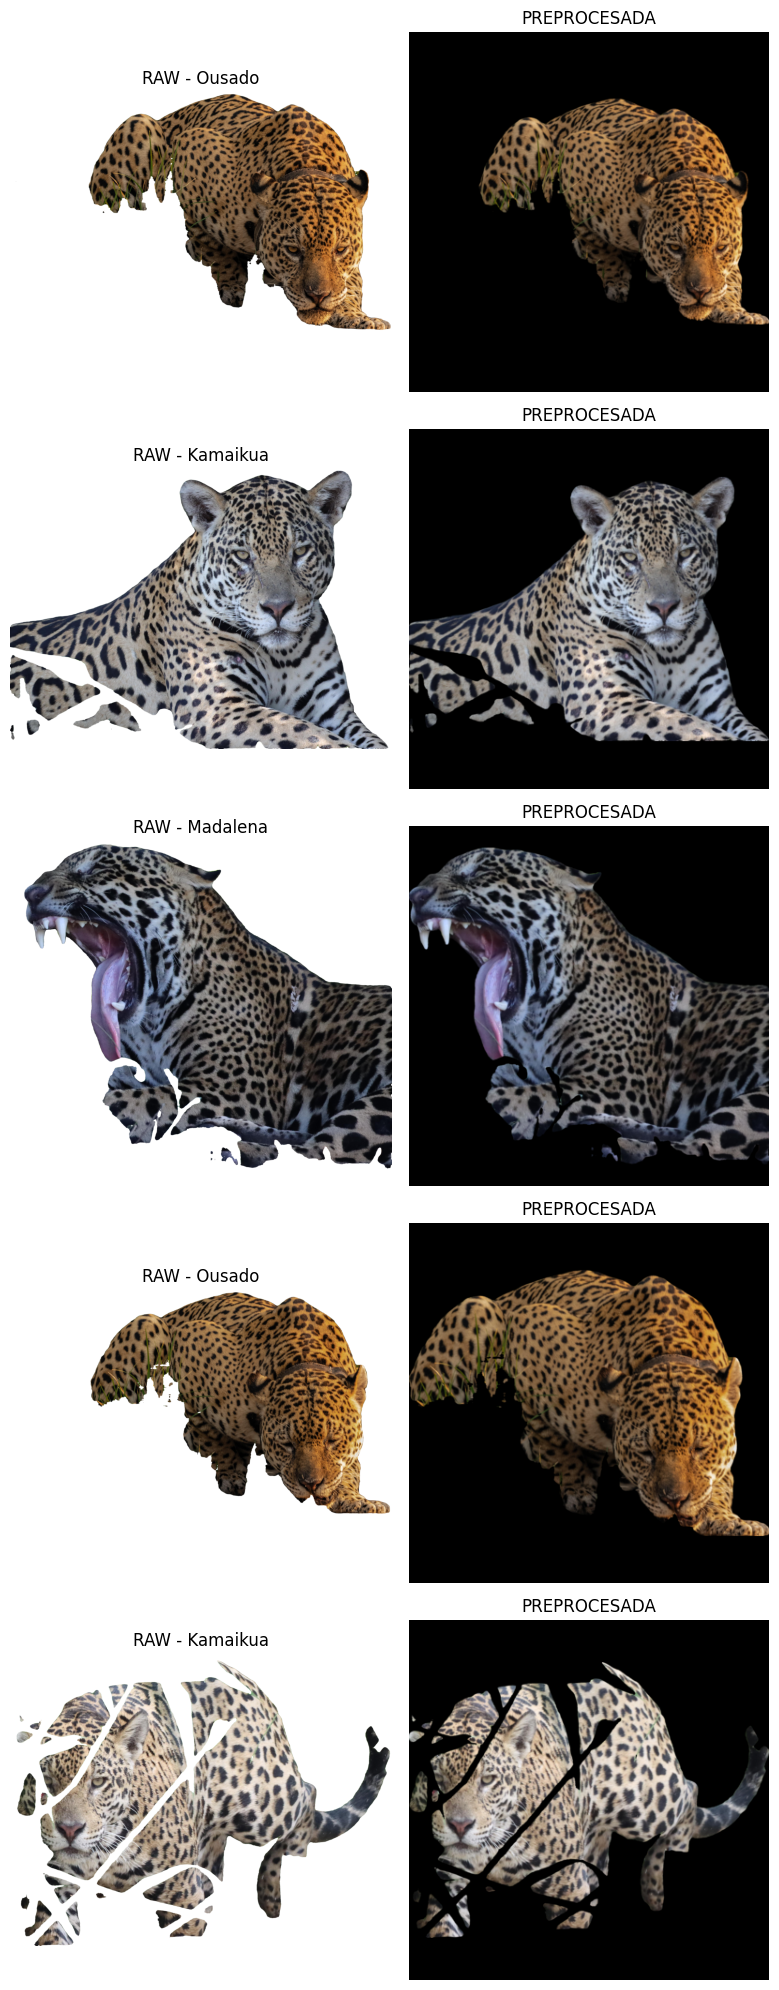

In [7]:
# ============================================================
# SANITY CHECK DEL PREPROCESSING
# ============================================================

def show_preprocessing_examples(df, n=6):
    sample_df = df.sample(n=min(n, len(df)), random_state=cfg.seed)

    fig, axes = plt.subplots(len(sample_df), 2, figsize=(8, 4 * len(sample_df)))

    if len(sample_df) == 1:
        axes = np.array([axes])

    for ax_row, (_, row) in zip(axes, sample_df.iterrows()):
        raw = Image.open(row["full_path"]).convert("RGBA")
        proc = preprocess_image(row["full_path"], cfg)

        ax_row[0].imshow(raw)
        ax_row[0].set_title(f"RAW - {row['ground_truth']}")
        ax_row[0].axis("off")

        ax_row[1].imshow(proc)
        ax_row[1].set_title("PREPROCESADA")
        ax_row[1].axis("off")

    plt.tight_layout()
    plt.show()

show_preprocessing_examples(train_df, n=5)

In [8]:
# ============================================================
# BLOQUE NUEVO — PREPROCESAR TRAIN A DISCO
# ============================================================

os.makedirs(cfg.offline_train_dir, exist_ok=True)

def build_offline_output_path(filename: str, cfg: CFG) -> str:
    stem = Path(filename).stem
    ext = cfg.offline_image_format.lower()
    return str(Path(cfg.offline_train_dir) / f"{stem}.{ext}")

def save_preprocessed_train_images(train_df: pd.DataFrame, cfg: CFG):
    """
    Recorre todo train_df, aplica el preprocessing base una sola vez
    y guarda las imágenes resultantes en disco.

    Esto evita repetir alpha crop + composición + resize + padding
    en cada epoch.
    """
    saved_paths = []

    for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Preprocesando train offline"):
        out_path = build_offline_output_path(row["filename"], cfg)

        # Si ya existe, no se reprocesa
        if not os.path.exists(out_path):
            img = preprocess_image(row["full_path"], cfg)

            if cfg.offline_image_format.lower() == "jpg":
                img.save(out_path, format="JPEG", quality=cfg.offline_jpg_quality)
            elif cfg.offline_image_format.lower() == "png":
                img.save(out_path, format="PNG")
            else:
                raise ValueError("offline_image_format debe ser 'jpg' o 'png'")

        saved_paths.append(out_path)

    return saved_paths


if cfg.use_offline_preprocessed:
    train_df["preprocessed_path"] = save_preprocessed_train_images(train_df, cfg)
else:
    train_df["preprocessed_path"] = train_df["full_path"]

print("Ejemplo de rutas preprocesadas:")
display(train_df[["filename", "full_path", "preprocessed_path"]].head())

Preprocesando train offline:   0%|          | 0/1895 [00:00<?, ?it/s]

Ejemplo de rutas preprocesadas:


,filename,full_path,preprocessed_path
0,train_0001.png,/kaggle/input/datasets/damontoyat/train-jaguar...,/kaggle/working/preprocessed_train_384/train_0...
1,train_0002.png,/kaggle/input/datasets/damontoyat/train-jaguar...,/kaggle/working/preprocessed_train_384/train_0...
2,train_0003.png,/kaggle/input/datasets/damontoyat/train-jaguar...,/kaggle/working/preprocessed_train_384/train_0...
3,train_0004.png,/kaggle/input/datasets/damontoyat/train-jaguar...,/kaggle/working/preprocessed_train_384/train_0...
4,train_0005.png,/kaggle/input/datasets/damontoyat/train-jaguar...,/kaggle/working/preprocessed_train_384/train_0...


### Carga test.csv y mapeaer paths

In [9]:
# ============================================================
# BLOQUE NUEVO — CARGA DE TEST
# ============================================================

from pathlib import Path

# ---- RUTAS DIRECTAS SOLO PARA ESTE BLOQUE ----
TEST_CSV_DIR = Path("/kaggle/input/datasets/damontoyat/test-csv-jaguars")
SAMPLE_SUB_DIR = Path("/kaggle/input/datasets/damontoyat/sample-submission-jaguars")
TEST_IMG_DIR = Path("/kaggle/input/datasets/damontoyat/test-jaguars")

# Buscar archivos csv dentro de las carpetas
test_csv_files = list(TEST_CSV_DIR.rglob("*.csv"))
sample_sub_files = list(SAMPLE_SUB_DIR.rglob("*.csv"))

assert len(test_csv_files) > 0, "No se encontró test.csv dentro de TEST_CSV_DIR"
assert len(sample_sub_files) > 0, "No se encontró sample_submission.csv dentro de SAMPLE_SUB_DIR"

test_csv_path = test_csv_files[0]
sample_submission_path = sample_sub_files[0]

print("Usando test.csv:", test_csv_path)
print("Usando sample_submission.csv:", sample_submission_path)

test_df = pd.read_csv(test_csv_path)
sample_submission = pd.read_csv(sample_submission_path)

# Mapear imágenes de test
test_image_files = list(TEST_IMG_DIR.rglob("*.png"))
test_name_to_path = {p.name: str(p) for p in test_image_files}

unique_test_images = sorted(set(test_df["query_image"]) | set(test_df["gallery_image"]))
test_images_df = pd.DataFrame({"filename": unique_test_images})
test_images_df["full_path"] = test_images_df["filename"].map(test_name_to_path)

assert test_images_df["full_path"].isnull().sum() == 0, "Hay imágenes de test sin path."

print("test_df shape:", test_df.shape)
print("Número de imágenes únicas de test:", len(test_images_df))
display(test_df.head())
display(test_images_df.head())

Usando test.csv: /kaggle/input/datasets/damontoyat/test-csv-jaguars/test.csv
Usando sample_submission.csv: /kaggle/input/datasets/damontoyat/sample-submission-jaguars/sample_submission.csv
test_df shape: (137270, 3)
Número de imágenes únicas de test: 371


,row_id,query_image,gallery_image
0,0,test_0001.png,test_0002.png
1,1,test_0001.png,test_0003.png
2,2,test_0001.png,test_0004.png
3,3,test_0001.png,test_0005.png
4,4,test_0001.png,test_0006.png


,filename,full_path
0,test_0001.png,/kaggle/input/datasets/damontoyat/test-jaguars...
1,test_0002.png,/kaggle/input/datasets/damontoyat/test-jaguars...
2,test_0003.png,/kaggle/input/datasets/damontoyat/test-jaguars...
3,test_0004.png,/kaggle/input/datasets/damontoyat/test-jaguars...
4,test_0005.png,/kaggle/input/datasets/damontoyat/test-jaguars...


In [10]:
# ============================================================
# BLOQUE NUEVO — PREPROCESAR TEST A DISCO
# ============================================================

os.makedirs(cfg.offline_test_dir, exist_ok=True)

def build_offline_test_output_path(filename: str, cfg: CFG) -> str:
    stem = Path(filename).stem
    ext = cfg.offline_image_format.lower()
    return str(Path(cfg.offline_test_dir) / f"{stem}.{ext}")

def save_preprocessed_test_images(test_images_df: pd.DataFrame, cfg: CFG):
    saved_paths = []

    for _, row in tqdm(test_images_df.iterrows(), total=len(test_images_df), desc="Preprocesando test offline"):
        out_path = build_offline_test_output_path(row["filename"], cfg)

        if not os.path.exists(out_path):
            img = preprocess_image(row["full_path"], cfg)

            if cfg.offline_image_format.lower() == "jpg":
                img.save(out_path, format="JPEG", quality=cfg.offline_jpg_quality)
            elif cfg.offline_image_format.lower() == "png":
                img.save(out_path, format="PNG")
            else:
                raise ValueError("offline_image_format debe ser 'jpg' o 'png'")

        saved_paths.append(out_path)

    return saved_paths

if cfg.use_offline_preprocessed:
    test_images_df["preprocessed_path"] = save_preprocessed_test_images(test_images_df, cfg)
else:
    test_images_df["preprocessed_path"] = test_images_df["full_path"]

display(test_images_df.head())

Preprocesando test offline:   0%|          | 0/371 [00:00<?, ?it/s]

,filename,full_path,preprocessed_path
0,test_0001.png,/kaggle/input/datasets/damontoyat/test-jaguars...,/kaggle/working/preprocessed_test_384/test_000...
1,test_0002.png,/kaggle/input/datasets/damontoyat/test-jaguars...,/kaggle/working/preprocessed_test_384/test_000...
2,test_0003.png,/kaggle/input/datasets/damontoyat/test-jaguars...,/kaggle/working/preprocessed_test_384/test_000...
3,test_0004.png,/kaggle/input/datasets/damontoyat/test-jaguars...,/kaggle/working/preprocessed_test_384/test_000...
4,test_0005.png,/kaggle/input/datasets/damontoyat/test-jaguars...,/kaggle/working/preprocessed_test_384/test_000...


### Transforms

In [11]:
mega_mean = [0.5, 0.5, 0.5]
mega_std  = [0.5, 0.5, 0.5]

train_transforms = T.Compose([
    T.RandomHorizontalFlip(p=cfg.hflip_prob),
    T.RandomApply(
        [T.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.08, hue=0.02)],
        p=cfg.color_jitter_prob
    ),
    T.RandomAffine(
        degrees=cfg.rotation_degrees,
        translate=(cfg.translate, cfg.translate),
        scale=(cfg.scale_min, cfg.scale_max)
    ),
    T.ToTensor(),
    T.Normalize(mean=mega_mean, std=mega_std),
])

valid_transforms = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=mega_mean, std=mega_std),
])

# FASE 4 - Dataset, Data Loaders y configuracion base

In [12]:
# ============================================================
# DATASET
# ============================================================

class JaguarDataset(Dataset):
    def __init__(self, df: pd.DataFrame, cfg: CFG, transforms=None, mode="train"):
        self.df = df.reset_index(drop=True).copy()
        self.cfg = cfg
        self.transforms = transforms
        self.mode = mode

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cfg.use_offline_preprocessed:
            img = Image.open(row["preprocessed_path"]).convert("RGB")
        else:
            img = preprocess_image(row["full_path"], self.cfg)

        if self.transforms is not None:
            img = self.transforms(img)

        label = int(row["label"])

        return {
            "image": img,
            "label": torch.tensor(label, dtype=torch.long),
            "filename": row["filename"],
            "identity": row["ground_truth"]
        }

In [13]:
# ============================================================
# BLOQUE NUEVO — TEST DATASET
# ============================================================

class JaguarTestDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transforms=None):
        self.df = df.reset_index(drop=True).copy()
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["preprocessed_path"]).convert("RGB")

        if self.transforms is not None:
            img = self.transforms(img)

        return {
            "image": img,
            "filename": row["filename"]
        }

In [14]:
# ============================================================
# BLOQUE NUEVO — TEST LOADER
# ============================================================

test_dataset = JaguarTestDataset(
    df=test_images_df,
    transforms=valid_transforms
)

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=True,
    drop_last=False
)

print("Test loader listo.")

Test loader listo.


### Weighted Sampler

Esto ayuda a que las clases raras tengan más presencia en entrenamiento sin duplicar archivos manualmente.

In [15]:
# ============================================================
# WEIGHTED SAMPLER
# ============================================================

def build_weighted_sampler(train_fold_df: pd.DataFrame):
    class_counts = train_fold_df["label"].value_counts().sort_index()
    class_weights = 1.0 / class_counts

    sample_weights = train_fold_df["label"].map(class_weights).values
    sample_weights = torch.DoubleTensor(sample_weights)

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    return sampler

### Función para crear loaders por fold

In [16]:
# ============================================================
# DATALOADERS POR FOLD
# ============================================================

def build_loaders_for_fold(train_df: pd.DataFrame, fold: int, cfg: CFG):
    train_fold_df = train_df[train_df["fold"] != fold].reset_index(drop=True)
    valid_fold_df = train_df[train_df["fold"] == fold].reset_index(drop=True)

    train_dataset = JaguarDataset(
        df=train_fold_df,
        cfg=cfg,
        transforms=train_transforms if cfg.use_train_aug else valid_transforms,
        mode="train"
    )

    valid_dataset = JaguarDataset(
        df=valid_fold_df,
        cfg=cfg,
        transforms=valid_transforms,
        mode="valid"
    )

    train_sampler = None
    shuffle = True

    if cfg.use_weighted_sampler:
        train_sampler = build_weighted_sampler(train_fold_df)
        shuffle = False

    train_loader = DataLoader(
        train_dataset,
        batch_size=cfg.batch_size,
        shuffle=shuffle,
        sampler=train_sampler,
        num_workers=cfg.num_workers,
        pin_memory=True,
        drop_last=True
    )

    valid_loader = DataLoader(
        valid_dataset,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=True,
        drop_last=False
    )

    return train_fold_df, valid_fold_df, train_loader, valid_loader

# FASE 5 — Validación y métricas

Aquí está una de las partes más importantes del notebook.

No queremos evaluar solo accuracy, sino también una métrica de retrieval alineada con el reto.

### Balanced mAP para validacion

In [17]:
# ============================================================
# METRICA DE VALIDACION: IDENTITY-BALANCED mAP
# ============================================================

def average_precision_at_k(relevant_mask: np.ndarray) -> float:
    """
    relevant_mask:
        vector booleano/0-1 indicando si cada elemento del ranking es relevante.
    """
    relevant_mask = relevant_mask.astype(np.int32)

    n_relevant = relevant_mask.sum()
    if n_relevant == 0:
        return 0.0

    precisions = []
    hits = 0

    for k, rel in enumerate(relevant_mask, start=1):
        if rel == 1:
            hits += 1
            precisions.append(hits / k)

    return float(np.sum(precisions) / n_relevant)


def compute_identity_balanced_map(embeddings: np.ndarray, labels: np.ndarray) -> float:
    """
    embeddings: (N, D), idealmente ya normalizados
    labels: (N,)
    
    Calcula un proxy muy alineado con la métrica de la competencia:
    - cosine similarity entre todas las imágenes de valid
    - para cada query, rankea el resto
    - calcula AP
    - promedia por identidad
    """
    # cosine similarity porque los embeddings vienen normalizados
    sim_matrix = embeddings @ embeddings.T

    n = len(labels)
    ap_per_query = []
    label_per_query = []

    for i in range(n):
        # excluimos self-comparison
        sims = sim_matrix[i].copy()
        sims[i] = -1e9

        order = np.argsort(-sims)
        ordered_labels = labels[order]

        relevant_mask = (ordered_labels == labels[i]).astype(np.int32)
        ap = average_precision_at_k(relevant_mask)

        ap_per_query.append(ap)
        label_per_query.append(labels[i])

    ap_df = pd.DataFrame({
        "label": label_per_query,
        "ap": ap_per_query
    })

    balanced_map = ap_df.groupby("label")["ap"].mean().mean()
    return float(balanced_map)

### Accuracy secundaria

La accuracy no es la métrica principal, pero sirve para monitoreo rápido.

In [18]:
# ============================================================
# METRICA SECUNDARIA: ACCURACY DE CLASIFICACION
# ============================================================

def compute_accuracy_from_logits(logits_list, labels_list):
    preds = np.concatenate([x.argmax(axis=1) for x in logits_list])
    targets = np.concatenate(labels_list)
    return accuracy_score(targets, preds)

# FASE 6 — Modelo, entrenamiento y fine-tuning
Decisión de arquitectura

Usaremos:

backbone timm

capa lineal a embedding

BatchNorm

normalización L2

head:

arcface o

linear

### ArcMarginProduct

In [19]:
# ============================================================
# ARC MARGIN PRODUCT
# ============================================================

class ArcMarginProduct(nn.Module):
    def __init__(self, in_features, out_features, s=30.0, m=0.35):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.m = m

        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, embeddings, labels):
        # embeddings ya deberían venir L2-normalizados
        cosine = F.linear(F.normalize(embeddings), F.normalize(self.weight))
        cosine = cosine.clamp(-1 + 1e-7, 1 - 1e-7)

        theta = torch.acos(cosine)
        target_logits = torch.cos(theta + self.m)

        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1), 1.0)

        logits = cosine * (1 - one_hot) + target_logits * one_hot
        logits *= self.s

        return logits

### MOdelo Principal

In [20]:
# ============================================================
# MODELO PRINCIPAL
# ============================================================

class JaguarReIDModel(nn.Module):
    def __init__(self, cfg: CFG, num_classes: int):
        super().__init__()
        self.cfg = cfg
        self.num_classes = num_classes

        # MegaDescriptor lo usamos como extractor de features tal como viene
        self.backbone = timm.create_model(cfg.model_name, pretrained=True)

        # Inferir dinámicamente la dimensión de salida del backbone
        with torch.no_grad():
            dummy = torch.zeros(1, 3, cfg.image_size, cfg.image_size)
            feats = self.backbone(dummy)
            if feats.ndim > 2:
                feats = feats.flatten(1)
            backbone_out = feats.shape[1]

        self.dropout = nn.Dropout(cfg.dropout)
        self.embedding = nn.Linear(backbone_out, cfg.embedding_dim)
        self.bn = nn.BatchNorm1d(cfg.embedding_dim)

        if cfg.head_type == "arcface":
            self.head = ArcMarginProduct(
                in_features=cfg.embedding_dim,
                out_features=num_classes,
                s=cfg.arcface_s,
                m=cfg.arcface_m
            )
        elif cfg.head_type == "linear":
            self.head = nn.Linear(cfg.embedding_dim, num_classes)
        else:
            raise ValueError("head_type debe ser 'arcface' o 'linear'")

    def forward(self, x, labels=None):
        feats = self.backbone(x)
        if feats.ndim > 2:
            feats = feats.flatten(1)

        feats = self.dropout(feats)
        emb = self.embedding(feats)
        emb = self.bn(emb)
        emb = F.normalize(emb, p=2, dim=1)

        logits = None
        if self.cfg.head_type == "arcface":
            if labels is not None:
                logits = self.head(emb, labels)
        else:
            logits = self.head(emb)

        return emb, logits

### Optimizer y scheduler

Usamos LR distinto para backbone y head.

In [21]:
# ============================================================
# OPTIMIZER Y SCHEDULER
# ============================================================

def build_optimizer(model: nn.Module, cfg: CFG):
    backbone_params = list(model.backbone.parameters())
    head_params = (
        list(model.embedding.parameters()) +
        list(model.bn.parameters()) +
        list(model.head.parameters())
    )

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": cfg.backbone_lr},
            {"params": head_params, "lr": cfg.head_lr},
        ],
        weight_decay=cfg.weight_decay
    )
    return optimizer


def build_scheduler(optimizer, cfg: CFG, steps_per_epoch: int):
    total_steps = cfg.epochs * steps_per_epoch
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=total_steps,
        eta_min=cfg.min_lr
    )
    return scheduler

### Train y valid loops

In [22]:
# ============================================================
# TRAIN LOOP
# ============================================================

def train_one_epoch(model, loader, optimizer, scheduler, scaler, device, cfg, model_ema=None):
    model.train()

    running_loss = 0.0
    n_batches = 0

    for batch in tqdm(loader, desc="Train", leave=False):
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=cfg.use_amp):
            embeddings, logits = model(images, labels)

            # ArcFace necesita labels para construir logits
            # Linear head genera logits directamente
            loss = F.cross_entropy(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        if model_ema is not None:
            model_ema.update(model)
        
        scheduler.step()

        running_loss += loss.item()
        n_batches += 1

    return running_loss / max(n_batches, 1)

In [23]:
# ============================================================
# VALID LOOP
# ============================================================

@torch.no_grad()
def valid_one_epoch(model, loader, device, cfg):
    model.eval()

    running_loss = 0.0
    n_batches = 0

    all_embeddings = []
    all_labels = []

    logits_list = []
    labels_list = []

    for batch in tqdm(loader, desc="Valid", leave=False):
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        with torch.cuda.amp.autocast(enabled=cfg.use_amp):
            embeddings, logits = model(images, labels)

            if logits is not None:
                loss = F.cross_entropy(logits, labels)
                running_loss += loss.item()
                n_batches += 1

        all_embeddings.append(embeddings.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())

        if logits is not None:
            logits_list.append(logits.detach().cpu().numpy())
            labels_list.append(labels.detach().cpu().numpy())

    all_embeddings = np.concatenate(all_embeddings, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    val_loss = running_loss / max(n_batches, 1)
    balanced_map = compute_identity_balanced_map(all_embeddings, all_labels)

    val_acc = None
    if len(logits_list) > 0:
        val_acc = compute_accuracy_from_logits(logits_list, labels_list)

    return {
        "val_loss": val_loss,
        "balanced_map": balanced_map,
        "val_acc": val_acc,
        "embeddings": all_embeddings,
        "labels": all_labels
    }

### Entrenamiento por fold

In [24]:
# ============================================================
# RUN DE UN FOLD
# ============================================================

def run_fold(train_df: pd.DataFrame, fold: int, cfg: CFG):
    print("=" * 80)
    print(f"FOLD {fold}")
    print("=" * 80)

    train_fold_df, valid_fold_df, train_loader, valid_loader = build_loaders_for_fold(
        train_df=train_df,
        fold=fold,
        cfg=cfg
    )

    print("Train shape:", train_fold_df.shape)
    print("Valid shape:", valid_fold_df.shape)

    model = JaguarReIDModel(cfg, num_classes=num_classes).to(device)

    model_ema = None
    if cfg.use_ema:
        model_ema = ModelEmaV2(model, decay=cfg.ema_decay, device=None)


    optimizer = build_optimizer(model, cfg)
    scheduler = build_scheduler(optimizer, cfg, steps_per_epoch=len(train_loader))
    scaler = torch.cuda.amp.GradScaler(enabled=cfg.use_amp)

    best_score = -np.inf
    best_path = os.path.join(cfg.output_dir, f"best_fold_{fold}.pth")

    history = []

    for epoch in range(cfg.epochs):
        print(f"\nEpoch {epoch + 1}/{cfg.epochs}")

        train_loss = train_one_epoch(
                        model=model,
                        loader=train_loader,
                        optimizer=optimizer,
                        scheduler=scheduler,
                        scaler=scaler,
                        device=device,
                        cfg=cfg,
                        model_ema=model_ema
                    )
        eval_model = model_ema.module if model_ema is not None else model
        valid_metrics = valid_one_epoch(
                        model=eval_model,
                        loader=valid_loader,
                        device=device,
                        cfg=cfg
                    )
        row = {
            "fold": fold,
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": valid_metrics["val_loss"],
            "balanced_map": valid_metrics["balanced_map"],
            "val_acc": valid_metrics["val_acc"]
        }
        history.append(row)

        print(
            f"train_loss={train_loss:.4f} | "
            f"val_loss={valid_metrics['val_loss']:.4f} | "
            f"balanced_map={valid_metrics['balanced_map']:.5f} | "
            f"val_acc={valid_metrics['val_acc']:.5f}"
        )

        # La métrica principal es balanced_map
        if valid_metrics["balanced_map"] > best_score:
            best_score = valid_metrics["balanced_map"]
            state_dict_to_save = model_ema.module.state_dict() if model_ema is not None else model.state_dict()
            torch.save({
                    "model_state_dict": state_dict_to_save,
                    "cfg": cfg,
                    "fold": fold,
                    "best_score": best_score,
                    "label_encoder_classes": le.classes_
                }, best_path)

            print(f"Nuevo mejor modelo guardado en: {best_path}")

    history_df = pd.DataFrame(history)

    # Liberar memoria
    del model, optimizer, scheduler, scaler, train_loader, valid_loader
    gc.collect()
    torch.cuda.empty_cache()

    return history_df, best_path

### Ejecutar 1 fold o todos
Recomendación práctica

Primero corre 1 fold para verificar que todo funciona y medir tiempo.

In [25]:
# ============================================================
# EJECUCION
# ============================================================

all_histories = []

if cfg.run_all_folds:
    folds_to_run = list(range(cfg.n_splits))
else:
    folds_to_run = [cfg.fold]

for fold in folds_to_run:
    history_df, best_path = run_fold(train_df, fold, cfg)
    all_histories.append(history_df)

history_df = pd.concat(all_histories, axis=0, ignore_index=True)
display(history_df)

FOLD 0
Train shape: (1516, 6)
Valid shape: (379, 6)


config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]


Epoch 1/15


Train:   0%|          | 0/189 [00:00<?, ?it/s]

...

train_loss=0.0266 | val_loss=0.9330 | balanced_map=0.75660 | val_acc=0.94459

Epoch 15/15


Train:   0%|          | 0/189 [00:00<?, ?it/s]

Valid:   0%|          | 0/48 [00:00<?, ?it/s]

train_loss=0.0157 | val_loss=0.9387 | balanced_map=0.75605 | val_acc=0.94459


,fold,epoch,train_loss,val_loss,balanced_map,val_acc
0,0,1,8.203462,7.599740,0.390570,0.218997
1,0,2,2.248949,3.203488,0.639074,0.678100
2,0,3,0.982248,2.193017,0.684411,0.802111
3,0,4,0.500506,1.919237,0.699405,0.854881
4,0,5,0.443151,1.821475,0.703010,0.873351
...,...,...,...,...,...,...
70,4,11,0.055406,0.925051,0.758631,0.939314
71,4,12,0.028776,0.928184,0.757348,0.941953
72,4,13,0.049395,0.925495,0.756618,0.941953
73,4,14,0.026593,0.932980,0.756596,0.944591


### Mejor Checkpoint

# ============================================================
# BLOQUE NUEVO — ENCONTRAR MEJOR CHECKPOINT
# ============================================================

best_row = history_df.sort_values("balanced_map", ascending=False).iloc[0]
best_fold = int(best_row["fold"])
best_epoch = int(best_row["epoch"])
best_score = float(best_row["balanced_map"])

best_ckpt_path = os.path.join(cfg.output_dir, f"best_fold_{best_fold}.pth")

print("Mejor fold:", best_fold)
print("Mejor epoch registrado:", best_epoch)
print("Mejor balanced_map:", best_score)
print("Checkpoint:", best_ckpt_path)
print("Existe:", os.path.exists(best_ckpt_path))

In [26]:
# ============================================================
# BLOQUE NUEVO — CHECKPOINTS DE TODOS LOS FOLDS
# ============================================================

fold_ckpt_paths = []
missing_ckpts = []

for fold in range(cfg.n_splits):
    ckpt_path = os.path.join(cfg.output_dir, f"best_fold_{fold}.pth")
    if os.path.exists(ckpt_path):
        fold_ckpt_paths.append(ckpt_path)
    else:
        missing_ckpts.append(ckpt_path)

print("Checkpoints encontrados:")
for p in fold_ckpt_paths:
    print(" -", p)

if len(missing_ckpts) > 0:
    print("\nCheckpoints faltantes:")
    for p in missing_ckpts:
        print(" -", p)

assert len(fold_ckpt_paths) > 0, "No se encontró ningún checkpoint de folds."

Checkpoints encontrados:
 - /kaggle/working/jaguar_reid_outputs_mega384/best_fold_0.pth
 - /kaggle/working/jaguar_reid_outputs_mega384/best_fold_1.pth
 - /kaggle/working/jaguar_reid_outputs_mega384/best_fold_2.pth
 - /kaggle/working/jaguar_reid_outputs_mega384/best_fold_3.pth
 - /kaggle/working/jaguar_reid_outputs_mega384/best_fold_4.pth


### Embedding de Test

In [27]:
# ============================================================
# BLOQUE NUEVO — EXTRAER EMBEDDINGS DE TEST
# ============================================================

@torch.no_grad()
def extract_test_embeddings(model, loader, device, cfg):
    model.eval()

    all_embeddings = []
    all_filenames = []

    for batch in tqdm(loader, desc="Extrayendo embeddings de test"):
        images = batch["image"].to(device)

        with torch.cuda.amp.autocast(enabled=cfg.use_amp):
            embeddings, _ = model(images, labels=None)

        all_embeddings.append(embeddings.detach().cpu().numpy())
        all_filenames.extend(batch["filename"])

    all_embeddings = np.concatenate(all_embeddings, axis=0)

    emb_df = pd.DataFrame({"filename": all_filenames})
    return emb_df, all_embeddings

### Cargar Mejor Modelo y extraer embeddings

# ============================================================
# BLOQUE NUEVO — INFERENCIA EN TEST
# ============================================================

checkpoint = torch.load(best_ckpt_path, map_location=device, weights_only=False)

best_model = JaguarReIDModel(cfg, num_classes=num_classes).to(device)
best_model.load_state_dict(checkpoint["model_state_dict"])

test_emb_df, test_embeddings = extract_test_embeddings(
    model=best_model,
    loader=test_loader,
    device=device,
    cfg=cfg
)

print(test_emb_df.shape, test_embeddings.shape)
display(test_emb_df.head())

### Similarities para test.csv

# ============================================================
# BLOQUE NUEVO — CONSTRUIR SUBMISSION
# ============================================================

# filename -> index en embeddings
test_img_to_idx = {fname: idx for idx, fname in enumerate(test_emb_df["filename"].tolist())}

# cosine similarity porque embeddings ya están normalizados
sim_matrix = test_embeddings @ test_embeddings.T

# Extraer score por cada fila de test.csv
similarities = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Construyendo similarities"):
    q_idx = test_img_to_idx[row["query_image"]]
    g_idx = test_img_to_idx[row["gallery_image"]]

    sim = sim_matrix[q_idx, g_idx]

    # mapear de [-1, 1] a [0, 1]
    sim = (sim + 1.0) / 2.0

    # clamp de seguridad
    sim = float(np.clip(sim, 0.0, 1.0))

    similarities.append(sim)

submission = pd.DataFrame({
    "row_id": test_df["row_id"],
    "similarity": similarities
})

display(submission.head())
print(submission.shape)

In [28]:
# ============================================================
# BLOQUE NUEVO — EXTRAER EMBEDDINGS DE UN CHECKPOINT
# ============================================================

@torch.no_grad()
def extract_test_embeddings_from_checkpoint(
    ckpt_path,
    test_loader,
    cfg,
    num_classes,
    device
):
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)

    model = JaguarReIDModel(cfg, num_classes=num_classes).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    all_embeddings = []
    all_filenames = []

    for batch in tqdm(test_loader, desc=f"Inferencia {Path(ckpt_path).name}"):
        images = batch["image"].to(device)

        with torch.cuda.amp.autocast(enabled=cfg.use_amp):
            embeddings, _ = model(images, labels=None)

        all_embeddings.append(embeddings.detach().cpu().numpy())
        all_filenames.extend(batch["filename"])

    all_embeddings = np.concatenate(all_embeddings, axis=0)

    del model
    gc.collect()
    torch.cuda.empty_cache()

    emb_df = pd.DataFrame({"filename": all_filenames})
    return emb_df, all_embeddings

In [29]:
# ============================================================
# BLOQUE NUEVO — ENSEMBLE DE EMBEDDINGS DE TODOS LOS FOLDS
# ============================================================

all_fold_embeddings = []
reference_filenames = None

for ckpt_path in fold_ckpt_paths:
    emb_df, emb_array = extract_test_embeddings_from_checkpoint(
        ckpt_path=ckpt_path,
        test_loader=test_loader,
        cfg=cfg,
        num_classes=num_classes,
        device=device
    )

    current_filenames = emb_df["filename"].tolist()

    if reference_filenames is None:
        reference_filenames = current_filenames
    else:
        assert current_filenames == reference_filenames, "El orden de filenames cambió entre folds."

    all_fold_embeddings.append(emb_array)

all_fold_embeddings = np.stack(all_fold_embeddings, axis=0)
print("Shape all_fold_embeddings:", all_fold_embeddings.shape)

ensemble_embeddings = all_fold_embeddings.mean(axis=0)

norms = np.linalg.norm(ensemble_embeddings, axis=1, keepdims=True)
ensemble_embeddings = ensemble_embeddings / np.clip(norms, 1e-12, None)

test_emb_df = pd.DataFrame({"filename": reference_filenames})

print("Shape ensemble_embeddings:", ensemble_embeddings.shape)
display(test_emb_df.head())

Inferencia best_fold_0.pth:   0%|          | 0/47 [00:00<?, ?it/s]

Inferencia best_fold_1.pth:   0%|          | 0/47 [00:00<?, ?it/s]

Inferencia best_fold_2.pth:   0%|          | 0/47 [00:00<?, ?it/s]

Inferencia best_fold_3.pth:   0%|          | 0/47 [00:00<?, ?it/s]

Inferencia best_fold_4.pth:   0%|          | 0/47 [00:00<?, ?it/s]

Shape all_fold_embeddings: (5, 371, 1024)
Shape ensemble_embeddings: (371, 1024)


,filename
0,test_0001.png
1,test_0002.png
2,test_0003.png
3,test_0004.png
4,test_0005.png


In [30]:
# ============================================================
# BLOQUE NUEVO — CONSTRUIR SUBMISSION CON ENSEMBLE DE FOLDS
# ============================================================

test_img_to_idx = {fname: idx for idx, fname in enumerate(test_emb_df["filename"].tolist())}

sim_matrix = ensemble_embeddings @ ensemble_embeddings.T

similarities = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Construyendo submission ensemble"):
    q_idx = test_img_to_idx[row["query_image"]]
    g_idx = test_img_to_idx[row["gallery_image"]]

    sim = sim_matrix[q_idx, g_idx]
    sim = (sim + 1.0) / 2.0
    sim = float(np.clip(sim, 0.0, 1.0))

    similarities.append(sim)

submission = pd.DataFrame({
    "row_id": test_df["row_id"],
    "similarity": similarities
})

display(submission.head())
print(submission.shape)

Construyendo submission ensemble:   0%|          | 0/137270 [00:00<?, ?it/s]

,row_id,similarity
0,0,0.767909
1,1,0.580773
2,2,0.564867
3,3,0.551833
4,4,0.602673


(137270, 2)


### Validacion final de submission

In [31]:
# ============================================================
# BLOQUE NUEVO — VALIDAR SUBMISSION
# ============================================================

assert submission.shape == (137270, 2), f"Shape incorrecto: {submission.shape}"
assert list(submission.columns) == ["row_id", "similarity"], "Columnas incorrectas"
assert submission["row_id"].tolist() == list(range(137270)), "row_id incorrecto"
assert np.isfinite(submission["similarity"]).all(), "Hay NaN o inf"
assert (submission["similarity"] >= 0).all(), "Hay valores < 0"
assert (submission["similarity"] <= 1).all(), "Hay valores > 1"

print("Submission válida.")
print(submission["similarity"].describe())

Submission válida.
count    137270.000000
mean          0.507574
std           0.095403
min           0.327611
25%           0.459494
50%           0.488373
75%           0.522180
max           0.999455
Name: similarity, dtype: float64


In [32]:
# ============================================================
# BLOQUE NUEVO — GUARDAR SUBMISSION
# ============================================================

submission_path = "/kaggle/working/submission_baseline_reid320_5.csv"
submission.to_csv(submission_path, index=False)

print("Submission guardada en:", submission_path)

Submission guardada en: /kaggle/working/submission_baseline_reid320_5.csv


### Visualizar curvas

In [ ]:
# ============================================================
# CURVAS DE ENTRENAMIENTO
# ============================================================

plt.figure(figsize=(8, 5))
for fold in history_df["fold"].unique():
    tmp = history_df[history_df["fold"] == fold]
    plt.plot(tmp["epoch"], tmp["balanced_map"], marker="o", label=f"fold {fold}")
plt.title("Balanced mAP por epoch")
plt.xlabel("Epoch")
plt.ylabel("balanced_map")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
for fold in history_df["fold"].unique():
    tmp = history_df[history_df["fold"] == fold]
    plt.plot(tmp["epoch"], tmp["train_loss"], marker="o", label=f"train fold {fold}")
    plt.plot(tmp["epoch"], tmp["val_loss"], marker="x", linestyle="--", label=f"valid fold {fold}")
plt.title("Loss por epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()